# Absenteeism forecasts — Chronos-Bolt, any sector

Report-ready charts for any SBI sector from **Chronos-Bolt**'s cross-validation outputs,
faithful to the prediction files (nothing is refit).

For a chosen sector this notebook produces:
1. **Back-test** — forecast vs. actual, every quarter.
2. **h=1 vs h=4 overlay** — short-lead vs. year-ahead accuracy.
3. **Chosen method vs. current baseline** — seasonal moving average from the gold DB.

### Notes
- Every value comes straight from `chronos_predictions.parquet` (`y_true`, `y_pred`). No confidence intervals.
- Chronos-Bolt's back-test covers ~2020→latest (20 outer folds), so its lines start around 2020.
- The winning correction (and model spec, for AutoETS) is read from `chronos_best_configs.json`.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# --- Method + global settings ------------------------------------------------
METHOD_LABEL      = "Chronos-Bolt"
PREDICTIONS_FILE  = "chronos_predictions.parquet"
BEST_CONFIGS_FILE = "chronos_best_configs.json"

COVID_START = pd.Timestamp("2020-03-31")
COVID_END   = pd.Timestamp("2022-06-30")
HIST_START  = "2015-01-01"
HORIZON     = 4
OUTPUT_DIR  = Path("images"); OUTPUT_DIR.mkdir(exist_ok=True)

SECTOR_TITLE_OVERRIDES = {}     # optional manual chart-title overrides

def _resolve(name, candidates=("cv_output", ".", "/mnt/user-data/uploads")):
    for d in candidates:
        p = Path(d) / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {name} in {candidates}")

PRED_PATH = _resolve(PREDICTIONS_FILE)
CFG_PATH  = _resolve(BEST_CONFIGS_FILE)
df_pred   = pd.read_parquet(PRED_PATH)
best_cfg  = json.loads(Path(CFG_PATH).read_text())

ALL_SECTORS = sorted(set(df_pred["sector_code"].astype(str)) & set(map(str, best_cfg)))
print(f"method      : {METHOD_LABEL}")
print(f"predictions : {PRED_PATH}")
print(f"best configs: {CFG_PATH}")
print(f"{len(ALL_SECTORS)} sectors available")

method      : Chronos-Bolt
predictions : cv_output\chronos_predictions.parquet
best configs: cv_output\chronos_best_configs.json
39 sectors available


In [2]:
# --- SBI titles for chart headers (from the silver DB) -----------------------
# Falls back to "Sector <code>" if the DB / src package isn't importable here.
import os, sys

SECTOR_TITLES = {}
try:
    _root = Path(os.getcwd()).resolve()
    for _ in range(8):                       # put project root on sys.path for `src` imports
        if (_root / "src" / "config.py").exists():
            if str(_root) not in sys.path:
                sys.path.insert(0, str(_root))
            break
        if _root.parent == _root:
            break
        _root = _root.parent

    from src.config import DIR_DB_SILVER
    from src.utils.m_query_database import f_query_database

    _titles_df = f_query_database(
        DIR_DB_SILVER,
        '''SELECT DISTINCT BedrijfskenmerkenSBI2008       AS sbi_code,
                          BedrijfskenmerkenSBI2008_Title AS sbi_title
           FROM "80072ned_silver"''',
        "pandas",
    )
    SECTOR_TITLES = dict(zip(_titles_df["sbi_code"], _titles_df["sbi_title"]))
    print(f"\u2705 loaded {len(SECTOR_TITLES)} SBI titles from the silver DB")
except Exception as exc:
    print(f"\u26a0\ufe0f could not load SBI titles ({type(exc).__name__}: {exc}) \u2014 using sector codes")

SECTOR_TITLES.update(SECTOR_TITLE_OVERRIDES)   # manual overrides win

✅ Query returned 39 rows from silver_data.db as pandas DataFrame


✅ loaded 39 SBI titles from the silver DB


In [3]:
# --- Helpers -----------------------------------------------------------------
GREY_LINE, GREY_LIGHT = "#9E9E9E", "#E0E0E0"
ORANGE_MAIN           = "#E8750A"
TEXT_DARK, TEXT_MID   = "#2D2D2D", "#6B6B6B"

def sector_title(code):
    return SECTOR_TITLES.get(str(code), f"Sector {code}")

def get_correction(sector):
    """Winning correction label, robust to flat-string or dict best_configs."""
    v = best_cfg.get(str(sector))
    if isinstance(v, dict):
        return v.get("winning_correction", "?")
    return v if v is not None else "?"

def method_detail(sector):
    """Correction (+ model spec when the config carries one) for the subtitle."""
    v = best_cfg.get(str(sector))
    if isinstance(v, dict) and v.get("best_model_spec"):
        return f"{v.get('winning_correction', '?')} \u00b7 {v['best_model_spec']}"
    return get_correction(sector)

def get_actuals(sector):
    sec = df_pred[df_pred["sector_code"].astype(str) == str(sector)]
    if sec.empty:
        raise KeyError(f"{sector} not in predictions file")
    return sec.groupby("target_date")["y_true"].first().sort_index().asfreq("QE")

def get_backtest_forecast(sector, horizon):
    sec = df_pred[(df_pred["sector_code"].astype(str) == str(sector)) &
                  (df_pred["horizon"] == horizon)]
    return sec.set_index("target_date")["y_pred"].sort_index()

def _style_axes(ax):
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GREY_LIGHT); ax.spines["bottom"].set_linewidth(0.8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
    ax.tick_params(length=0, colors=TEXT_MID, labelsize=9.5, pad=8)
    ax.grid(axis="y", color=GREY_LIGHT, linewidth=0.5, zorder=0)
    ax.grid(axis="x", visible=False)

def _covid_band(ax):
    ax.axvspan(COVID_START, COVID_END, color=GREY_LIGHT, alpha=0.5, zorder=0)
    ax.text(COVID_START + (COVID_END - COVID_START) / 2, 0.97, "COVID Pandemic",
            color=TEXT_MID, fontsize=9, fontweight="medium", ha="center", va="top",
            transform=ax.get_xaxis_transform())

def _titles(ax, title, subtitle):
    ax.text(0.0, 1.12, title, transform=ax.transAxes, fontsize=16, fontweight="bold",
            color=TEXT_DARK, ha="left", va="bottom")
    ax.text(0.0, 1.04, subtitle, transform=ax.transAxes, fontsize=10.5,
            color=TEXT_MID, ha="left", va="bottom")

In [4]:
def plot_backtest(sector, horizon=HORIZON, hist_start=HIST_START, show=True):
    actuals = get_actuals(sector)
    fc = get_backtest_forecast(sector, horizon)
    df_ts = actuals[actuals.index >= hist_start]
    df_fc = fc[fc.index >= hist_start]
    ov = pd.concat([df_ts.rename("a"), df_fc.rename("f")], axis=1).dropna()
    mae = (ov["a"] - ov["f"]).abs().mean()
    mape = ((ov["a"] - ov["f"]).abs() / ov["a"]).mean() * 100

    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)
    ax.plot(df_ts.index, df_ts.values, linewidth=2.2, color=GREY_LINE, zorder=2, label="Actual")
    lead = "one year ahead" if horizon == 4 else f"{horizon}q ahead"
    ax.plot(df_fc.index, df_fc.values, linewidth=2.0, color=ORANGE_MAIN, zorder=3,
            marker="o", markersize=3.2, markerfacecolor="white", markeredgecolor=ORANGE_MAIN,
            markeredgewidth=1.0, label=f"Forecast (h={horizon}, {lead})")
    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    if len(ov):
        yrs = f"{ov.index.min().year}\u2013{ov.index.max().year}"
        ax.text(0.995, 0.06, f"Back-test accuracy ({yrs}):  MAE {mae:.2f} pp   \u00b7   MAPE {mape:.1f}%",
                transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color=TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"{METHOD_LABEL} back-test: forecast vs. actual, every quarter  \u00b7  {method_detail(sector)}")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    out = OUTPUT_DIR / f"{sector}_{METHOD_LABEL}_backtest_h{horizon}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out, {"mae": round(float(mae), 3), "mape": round(float(mape), 2)}


def run_sector(sector, show=True):
    """Generate the back-test chart for one sector."""
    if str(sector) not in set(map(str, best_cfg)):
        print(f"\u26a0\ufe0f {sector}: not in best_configs \u2014 skipping"); return None
    path, acc = plot_backtest(sector, show=show)
    return {"sector": sector, "correction": get_correction(sector),
            "backtest_png": path, "accuracy": acc}

## Run one sector
Set `SECTOR` and run. The image is written to `images/`.

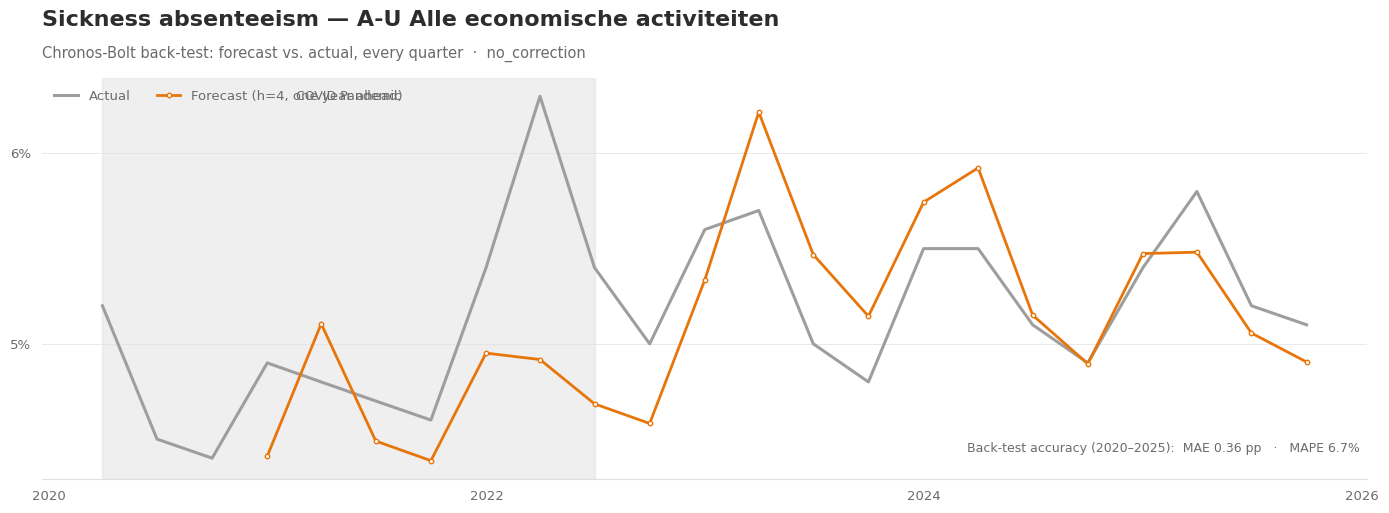

correction: no_correction | accuracy: {'mae': 0.361, 'mape': 6.72}


In [5]:
SECTOR = "T001081"          # <-- change to any code in ALL_SECTORS

result = run_sector(SECTOR, show=True)
print("correction:", result["correction"], "| accuracy:", result.get("accuracy"))

## Variant — actual vs. h=1 and h=4 on one chart
Overlays the short-lead (h=1) and year-ahead (h=4) forecasts. Darker = shorter lead. Note
h=1 ends one fold earlier than h=4 (the last origin can't be scored at every horizon).

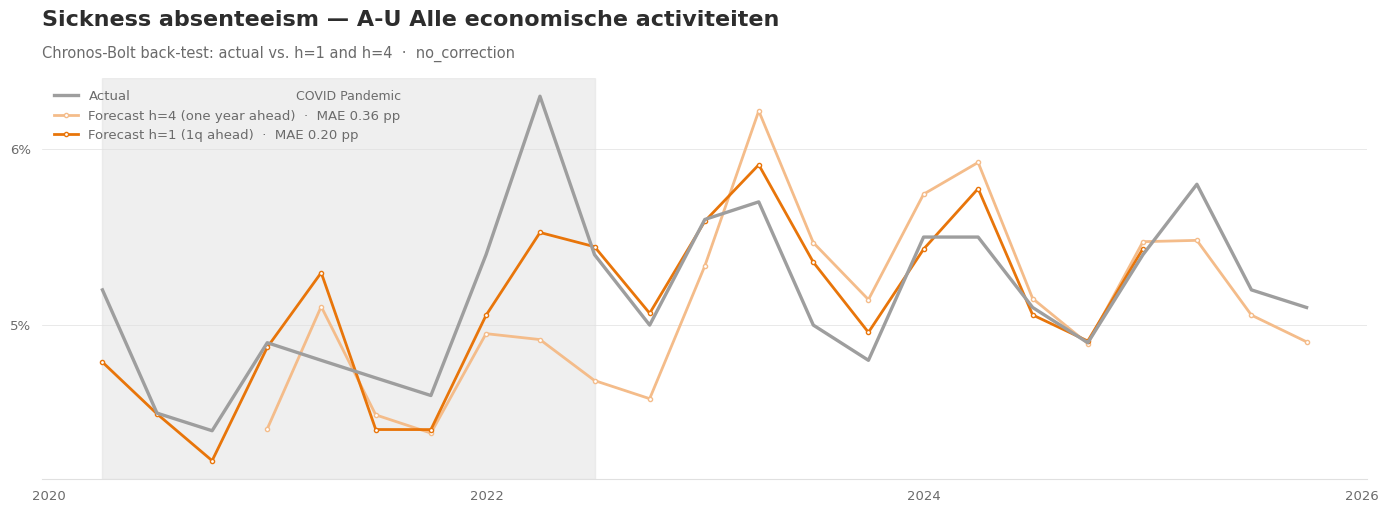

WindowsPath('images/T001081_Chronos-Bolt_overlay_h1_h4.png')

In [6]:
def plot_overlay_h1_h4(sector, horizons=(1, 4), hist_start=HIST_START, show=True):
    actuals = get_actuals(sector)
    df_ts = actuals[actuals.index >= hist_start]
    colors = {1: "#E8750A", 2: "#EC8A2E", 3: "#F0A35C", 4: "#F4BC8A"}
    series = {}
    for h in horizons:
        fc = get_backtest_forecast(sector, h)
        fc = fc[fc.index >= hist_start]
        ov = pd.concat([df_ts.rename("a"), fc.rename("f")], axis=1).dropna()
        series[h] = (fc, (ov["a"] - ov["f"]).abs().mean())

    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)
    ax.plot(df_ts.index, df_ts.values, linewidth=2.4, color=GREY_LINE, zorder=10, label="Actual")
    for h in sorted(horizons, reverse=True):
        fc, mae = series[h]
        lead = "1q ahead" if h == 1 else ("one year ahead" if h == 4 else f"{h}q ahead")
        ax.plot(fc.index, fc.values, linewidth=2.0, color=colors.get(h, ORANGE_MAIN),
                zorder=10 - h, marker="o", markersize=3.0, markerfacecolor="white",
                markeredgecolor=colors.get(h, ORANGE_MAIN), markeredgewidth=1.0,
                label=f"Forecast h={h} ({lead})  \u00b7  MAE {mae:.2f} pp")
    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=1, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"{METHOD_LABEL} back-test: actual vs. "
            f"{' and '.join('h=%d' % h for h in sorted(horizons))}  \u00b7  {method_detail(sector)}")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    tag = "_".join(f"h{h}" for h in sorted(horizons))
    out = OUTPUT_DIR / f"{sector}_{METHOD_LABEL}_overlay_{tag}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out

plot_overlay_h1_h4(SECTOR)

## Variant — chosen method vs. current baseline
Overlays actuals (grey), **Chronos-Bolt** at h=1 (dark orange), and the current production
baseline — seasonal moving average (blue) — read from the gold DB
(`prediction_baseline_total` / `_sbi` / `_compsize`). Both MAEs are scored on the common
window. Set `GOLD_DB` if it can't be auto-located; if missing, the blue line is skipped.

In [7]:
# \u2500\u2500 Current-method BASELINE (seasonal moving average) from the GOLD DB \u2500\u2500\u2500\u2500\u2500\u2500
# The gold DB stores one baseline_prediction per sector per quarter across these tables.
import os, sqlite3

BASELINE_TABLES = ["prediction_baseline_total",
                   "prediction_baseline_sbi",
                   "prediction_baseline_compsize"]

def _resolve_gold_db():
    """Locate gold_data.db: an explicit GOLD_DB -> src.config.DIR_DB_GOLD ->
    <project_root>/data/3_gold/gold_data.db -> a few relative guesses."""
    try:
        if GOLD_DB:
            return Path(GOLD_DB)
    except NameError:
        pass
    try:
        from src.config import DIR_DB_GOLD
        return Path(DIR_DB_GOLD)
    except Exception:
        pass
    here = Path(os.getcwd()).resolve()
    for base in [here, *here.parents]:
        cand = base / "data" / "3_gold" / "gold_data.db"
        if cand.exists():
            return cand
    for cand in ("data/3_gold/gold_data.db", "../data/3_gold/gold_data.db",
                 "../../data/3_gold/gold_data.db", "gold_data.db"):
        if Path(cand).exists():
            return Path(cand)
    return None

def _load_baseline_preds():
    db = _resolve_gold_db()
    if db is None or not Path(db).exists():
        print("\u26a0\ufe0f gold DB not found \u2014 set GOLD_DB; baseline (blue) line will be skipped")
        return None
    frames = []
    with sqlite3.connect(str(db)) as con:
        existing = {r[0] for r in con.execute(
            "SELECT name FROM sqlite_master WHERE type='table'")}
        for t in BASELINE_TABLES:
            if t not in existing:
                continue
            cols = {r[1] for r in con.execute(f'PRAGMA table_info("{t}")')}
            if not {"sbi_code", "period_enddate", "baseline_prediction"} <= cols:
                continue
            sel = ["sbi_code", "period_enddate", "baseline_prediction"]
            if "absenteeism_perc" in cols:
                sel.append("absenteeism_perc")
            frames.append(pd.read_sql(f'SELECT {", ".join(sel)} FROM "{t}"', con))
    if not frames:
        print("\u26a0\ufe0f no prediction_baseline_* tables in gold DB \u2014 baseline skipped")
        return None
    df = pd.concat(frames, ignore_index=True)
    df["sbi_code"] = df["sbi_code"].astype(str)
    df["period_enddate"] = pd.to_datetime(df["period_enddate"], errors="coerce")
    df["baseline_prediction"] = pd.to_numeric(df["baseline_prediction"], errors="coerce")
    df = df.dropna(subset=["period_enddate", "baseline_prediction"])
    print(f"\u2705 baseline loaded from gold DB: {len(df):,} rows, "
          f"{df['sbi_code'].nunique()} sectors")
    return df

baseline_preds = _load_baseline_preds()

def get_baseline_series(sector):
    """Per-quarter baseline (seasonal moving average) for one sector, from the gold DB."""
    if baseline_preds is None or baseline_preds.empty:
        return None
    b = baseline_preds[baseline_preds["sbi_code"].astype(str) == str(sector)].copy()
    if b.empty:
        return None
    # one value per quarter (dedupe defensively if a code appears in >1 table)
    s = b.groupby("period_enddate")["baseline_prediction"].mean().sort_index()
    s.index = pd.DatetimeIndex(s.index)
    return s

✅ baseline loaded from gold DB: 989 rows, 23 sectors


   baseline: 23 pts, 2020-03-31 -> 2025-09-30


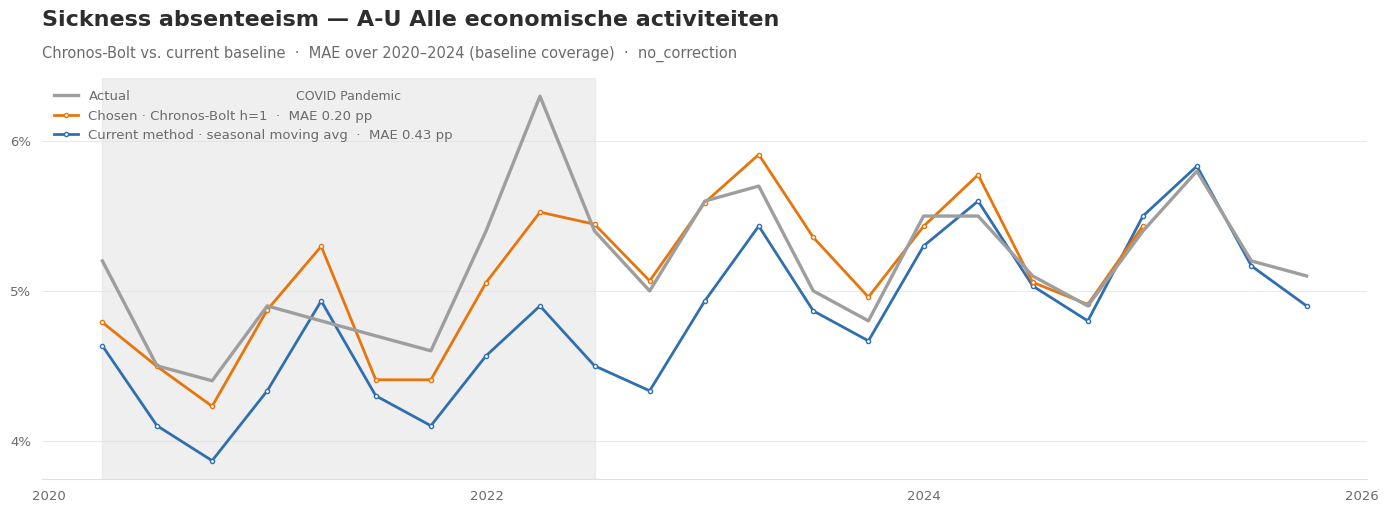

WindowsPath('images/T001081_Chronos-Bolt_vs_baseline_h1.png')

In [8]:
def plot_vs_baseline(sector, horizon=1, hist_start=HIST_START, show=True):
    """Actual vs. chosen method (short-lead) vs. current baseline (seasonal moving avg).
    Both MAEs are computed on the same window (where the baseline exists)."""
    actuals = get_actuals(sector)
    df_ts = actuals[actuals.index >= hist_start]
    chosen = get_backtest_forecast(sector, horizon)
    chosen = chosen[chosen.index >= hist_start]
    base = get_baseline_series(sector)
    if base is not None and len(df_ts):
        # Clip the baseline to the method's actual window so all three lines align
        # (these methods' actuals start ~2020, while the gold baseline goes back further).
        base = base[(base.index >= df_ts.index.min()) & (base.index <= df_ts.index.max())]
        print(f"   baseline: {len(base)} pts, {base.index.min().date()} -> {base.index.max().date()}")
    else:
        base = None
        print("   baseline: none for this sector (blue line skipped)")

    common = df_ts.index.intersection(chosen.index)
    if base is not None and len(base):
        common = common.intersection(base.index)

    def _mae(s):
        if s is None or not len(common):
            return float("nan")
        ov = pd.concat([df_ts, s], axis=1, keys=["a", "f"]).reindex(common).dropna()
        return (ov["a"] - ov["f"]).abs().mean() if len(ov) else float("nan")

    chosen_mae, base_mae = _mae(chosen), _mae(base)
    win = f"{common.min().year}\u2013{common.max().year}" if len(common) else "n/a"

    BLUE = "#2F6FB0"
    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)
    ax.plot(df_ts.index, df_ts.values, linewidth=2.4, color=GREY_LINE, zorder=5, label="Actual")
    ax.plot(chosen.index, chosen.values, linewidth=2.0, color=ORANGE_MAIN, zorder=4,
            marker="o", markersize=3.0, markerfacecolor="white", markeredgecolor=ORANGE_MAIN,
            markeredgewidth=1.0,
            label=f"Chosen \u00b7 {METHOD_LABEL} h={horizon}  \u00b7  MAE {chosen_mae:.2f} pp")
    if base is not None and len(base):
        ax.plot(base.index, base.values, linewidth=2.0, color=BLUE, zorder=3,
                marker="o", markersize=3.0, markerfacecolor="white", markeredgecolor=BLUE,
                markeredgewidth=1.0,
                label=f"Current method \u00b7 seasonal moving avg  \u00b7  MAE {base_mae:.2f} pp")
    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=1, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"{METHOD_LABEL} vs. current baseline  \u00b7  MAE over {win} (baseline coverage)"
            f"  \u00b7  {method_detail(sector)}")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    out = OUTPUT_DIR / f"{sector}_{METHOD_LABEL}_vs_baseline_h{horizon}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out

plot_vs_baseline(SECTOR)

## Batch — generate back-test images for many sectors
Runs silently and writes one PNG per sector to `images/`. Edit `SECTORS_TO_RUN`.

In [9]:
SECTORS_TO_RUN = ALL_SECTORS      # e.g. ["T001081", "300003", "350000"]

summary = []
for i, code in enumerate(SECTORS_TO_RUN, 1):
    print(f"[{i}/{len(SECTORS_TO_RUN)}] {code} ({get_correction(code)})")
    try:
        r = run_sector(code, show=False)
        if r:
            summary.append({"sector": code, "correction": r["correction"],
                            "mae": r.get("accuracy", {}).get("mae"),
                            "mape": r.get("accuracy", {}).get("mape")})
    except Exception as exc:
        print(f"   \u26a0\ufe0f {code} failed: {exc}")

summary_df = pd.DataFrame(summary)
print(f"\nDone. PNGs in {OUTPUT_DIR.resolve()}")
display(summary_df)

[1/39] 300003 (no_correction)
[2/39] 300007 (no_correction)
[3/39] 300013 (no_correction|winsorized)
[4/39] 301000 (no_correction)
[5/39] 305700 (no_correction)
[6/39] 307500 (no_correction)
[7/39] 307610 (no_correction)
[8/39] 317105 (no_correction)
[9/39] 320005 (no_correction|winsorized)
[10/39] 328110 (no_correction)
[11/39] 346600 (no_correction)
[12/39] 348000 (no_correction|winsorized)
[13/39] 350000 (no_correction)
[14/39] 354200 (no_correction)
[15/39] 354300 (no_correction|winsorized)
[16/39] 356900 (no_correction)
[17/39] 371600 (no_correction)
[18/39] 383100 (no_correction)
[19/39] 383200 (no_correction)
[20/39] 389100 (no_correction|winsorized)
[21/39] 391600 (no_correction)
[22/39] 396300 (no_correction)
[23/39] 402000 (no_correction)
[24/39] 403300 (no_correction|winsorized)
[25/39] 410200 (no_correction)
[26/39] 415300 (no_correction)
[27/39] 417400 (no_correction)
[28/39] 419000 (no_correction|winsorized)
[29/39] 422400 (no_correction)
[30/39] 422500 (no_correction|win

,sector,correction,mae,mape
0,300003,no_correction,0.422,7.24
1,300007,no_correction,0.312,6.83
2,300013,no_correction|winsorized,0.462,7.06
3,301000,no_correction,0.403,11.26
4,305700,no_correction,0.292,5.96
5,307500,no_correction,0.453,7.19
6,307610,no_correction,0.581,9.41
7,317105,no_correction,0.530,8.43
8,320005,no_correction|winsorized,0.520,8.50
9,328110,no_correction,0.369,6.73
